# Predicting House Prices with Linear Regression
**0ASIS INFOBYTE SIP -Data Analytics Level 1-Task 1**

Objective: Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

Tech Stack: Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Feature Checklist:**

**Load dataset and perform EDA:** null check, descriptive statistics, distribution of the target variable (price)
**Feature selection discussion:** identify which features are likely predictors; explain reasoning in a markdown cell
3.Handle missing values and encode categorical features (One-Hot Encoding)
 **Correlation heatmap:**identify features most correlated with house price
• Train/test split (80/20)
• Train a Linear Regression model using scikit-learn
• Evaluate model using: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score
**Scatter plot:** actual prices vs. predicted prices (the closer to a diagonal line, the better)
• **Residual plot:** check that residuals are randomly distributed (no systematic pattern)
• **Coefficient analysis:** which features have the highest positive/negative impact on price?
•**(Bonus)** Compare Linear Regression against a Ridge or Lasso regularised model

Self-Sourcing : "Ames Housing Dataset" on Kaggle.com 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# 1.Load Dataset and Perform EDA

In [2]:
df=pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [4]:
df.shape

(2930, 82)

In [5]:
df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

In [6]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.mean(numeric_only=True)

Order              1.465500e+03
PID                7.144645e+08
MS SubClass        5.738737e+01
Lot Frontage       6.922459e+01
Lot Area           1.014792e+04
Overall Qual       6.094881e+00
Overall Cond       5.563140e+00
Year Built         1.971356e+03
Year Remod/Add     1.984267e+03
Mas Vnr Area       1.018968e+02
BsmtFin SF 1       4.426296e+02
BsmtFin SF 2       4.972243e+01
Bsmt Unf SF        5.592625e+02
Total Bsmt SF      1.051615e+03
1st Flr SF         1.159558e+03
2nd Flr SF         3.354560e+02
Low Qual Fin SF    4.676792e+00
Gr Liv Area        1.499690e+03
Bsmt Full Bath     4.313525e-01
Bsmt Half Bath     6.113388e-02
Full Bath          1.566553e+00
Half Bath          3.795222e-01
Bedroom AbvGr      2.854266e+00
Kitchen AbvGr      1.044369e+00
TotRms AbvGrd      6.443003e+00
Fireplaces         5.993174e-01
Garage Yr Blt      1.978132e+03
Garage Cars        1.766815e+00
Garage Area        4.728197e+02
Wood Deck SF       9.375188e+01
Open Porch SF      4.753345e+01
Enclosed

In [9]:
df.median(numeric_only=True)

Order                   1465.5
PID                535453620.0
MS SubClass               50.0
Lot Frontage              68.0
Lot Area                9436.5
Overall Qual               6.0
Overall Cond               5.0
Year Built              1973.0
Year Remod/Add          1993.0
Mas Vnr Area               0.0
BsmtFin SF 1             370.0
BsmtFin SF 2               0.0
Bsmt Unf SF              466.0
Total Bsmt SF            990.0
1st Flr SF              1084.0
2nd Flr SF                 0.0
Low Qual Fin SF            0.0
Gr Liv Area             1442.0
Bsmt Full Bath             0.0
Bsmt Half Bath             0.0
Full Bath                  2.0
Half Bath                  0.0
Bedroom AbvGr              3.0
Kitchen AbvGr              1.0
TotRms AbvGrd              6.0
Fireplaces                 1.0
Garage Yr Blt           1979.0
Garage Cars                2.0
Garage Area              480.0
Wood Deck SF               0.0
Open Porch SF             27.0
Enclosed Porch             0.0
3Ssn Por

In [10]:
df.mode(numeric_only=True).iloc[0]

Order                      1.0
PID                526301100.0
MS SubClass               20.0
Lot Frontage              60.0
Lot Area                9600.0
Overall Qual               5.0
Overall Cond               5.0
Year Built              2005.0
Year Remod/Add          1950.0
Mas Vnr Area               0.0
BsmtFin SF 1               0.0
BsmtFin SF 2               0.0
Bsmt Unf SF                0.0
Total Bsmt SF              0.0
1st Flr SF               864.0
2nd Flr SF                 0.0
Low Qual Fin SF            0.0
Gr Liv Area              864.0
Bsmt Full Bath             0.0
Bsmt Half Bath             0.0
Full Bath                  2.0
Half Bath                  0.0
Bedroom AbvGr              3.0
Kitchen AbvGr              1.0
TotRms AbvGrd              6.0
Fireplaces                 0.0
Garage Yr Blt           2005.0
Garage Cars                2.0
Garage Area                0.0
Wood Deck SF               0.0
Open Porch SF              0.0
Enclosed Porch             0.0
3Ssn Por

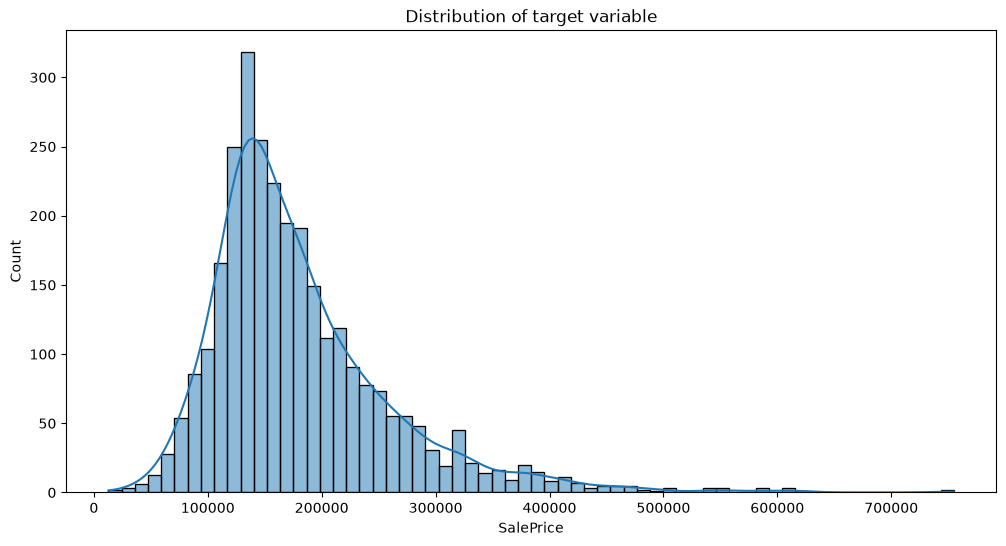

In [13]:
plt.figure(figsize=(12,6))
sns.histplot(data=df,x="SalePrice",kde=True)
plt.title("Distribution of target variable")
plt.savefig("screenshots/Distribution of target variable.png")
plt.show()

Loading Ames Housing dataset from Kaggle. Performing Exploratory Data Analysis - checking null values using isnull().sum(), descriptive statistics using describe(), and plotting distribution of target variable SalePrice to check skewness.

# 2. Feature selection discussion

Feature Selection:
- Numerical: GrLivArea, TotalBsmtSF, GarageArea, OverallQual are highly correlated with price.
  Reason: Bigger living area = higher price, Quality rating directly increases value.
- Categorical: Neighborhood, HouseStyle impact price due to location premium.
- Dropping: Id, low variance columns. This improves model interpretability.



From EDA, features like OverallQual (Overall material and finish quality), GrLivArea (Above ground living area), GarageCars, TotalBsmtSF are likely to be strong predictors because houses with better quality and larger area cost more. Location features like Neighborhood and MSZoning also impact price. Age-related features like YearBuilt can have negative correlation if old.

# 3.Handle Missing value and One-Hot Encoding

In [19]:
columns=df.select_dtypes(include=[np.number]).columns.drop="SalePrice"
categorial=df.select_dtypes(include=['object']).columns

C:\Users\T Archana\AppData\Local\Temp\ipykernel_23344\2194106522.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorial=df.select_dtypes(include=['object']).columns


In [17]:
for col in columns:
    df[col].fillna(df[col].median())
for col in categorial:
    df[col].fillna("Missing")

In [41]:
df_encoded=pd.get_dummies(df,columns=categorial,drop_first=True)
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Handling missing values: Numerical NaNs filled with median to avoid outlier impact, Categorical NaNs filled with mode (most frequent). Encoding categorical variables like MSZoning, Neighborhood, HouseStyle using One-Hot Encoding (pd.get_dummies) because Linear Regression requires only numerical input.

# 4.Correlation Heatmap

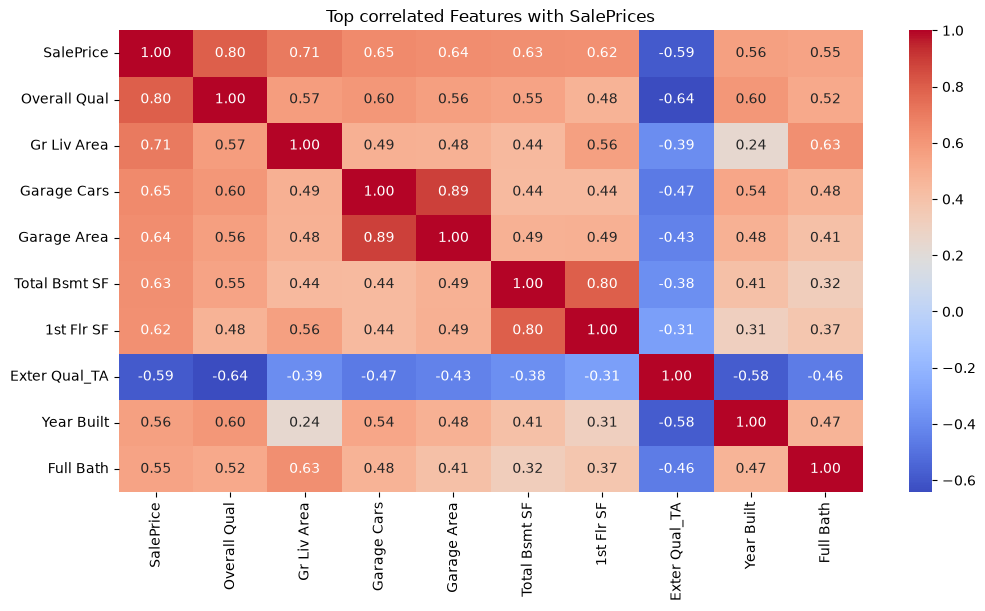

In [ ]:
plt.figure(figsize=(12,6))
top_corr=df_encoded.corr()["SalePrice"].abs().sort_values(ascending=False).head(10).index
sns.heatmap(df_encoded[top_corr].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Top correlated Features with SalePrices")
plt.savefig("screenshots/Top correlated Features with SalePrices.png")
plt.show()

Creating correlation matrix using df.corr() and using abs() to consider both positive and negative correlations. Identifying top 10 features most correlated with SalePrice. OverallQual and GrLivArea show highest positive correlation. Plotting heatmap using seaborn for better visualization.

# 5.Train/test split(80/20)

In [29]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [31]:
print(X_train.isnull().sum().sum()) # should be 0, if not 0 -> error
print(X_train.dtypes.value_counts()) # should be only int64, float64, bool

# FIX - if you have NaN
# 1. Fill NaN
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# 2. Make sure all are numbers
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test[X_train.columns] # same columns


542
bool       224
int64       27
float64     11
Name: count, dtype: int64


Splitting data into 80% training and 20% testing using train_test_split(test_size=0.2, random_state=42). Training set is used to learn the model, testing set is used to evaluate performance on unseen data. X contains features, y contains SalePrice.

# 6.LinearRegreesion Model

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)



Training Linear Regression model using sklearn.linear_model.LinearRegression(). The model learns equation: SalePrice = m1*Feature1 + m2*Feature2 + ... + c. Using lr.fit(X_train, y_train) to train.

# 7.Evalute models using MSE,RMSE,R²score

In [33]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}\nRMSE: {rmse:.2f}\nR2 Score: {r2:.4f}")



MSE: 1303221916.72
RMSE: 36100.17
R2 Score: 0.8375


Evaluating model performance:
- MSE (Mean Squared Error): Average of squared errors. Lower is better.
- RMSE (Root Mean Squared Error): Square root of MSE, in same unit as price.
- R2 Score: Proportion of variance explained by model (0 to 1). Higher is better, close to 1 means good fit.

# 8.Scatter plot

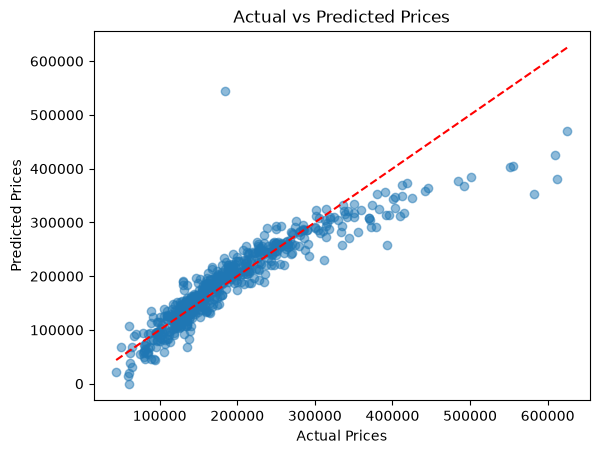

In [35]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.savefig("screenshots/Actual vs Predicted Prices.png")
plt.show()



Plotting actual prices (y_test) vs predicted prices (y_pred). If points are closer to diagonal line (y=x), model prediction is accurate. Shows how well model generalizes.

# 9.Residual plot

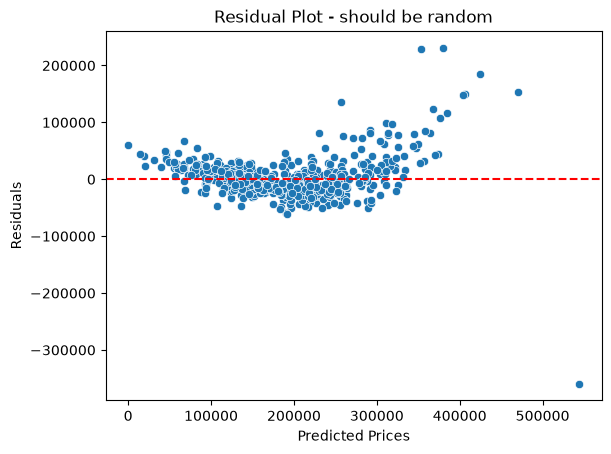

In [ ]:
residuals = y_test - y_pred
plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot - should be random")
plt.savefig("screenshots/Residual Plot - should be random.png")
plt.show()


Plotting residuals (y_test - y_pred) vs predicted prices. Checking if residuals are randomly distributed around 0 with no systematic pattern. Random distribution indicates linear regression assumptions are met. If pattern exists, model needs improvement.

# 10. Coefficient Analysis

           Feature   Coefficient
5     Overall Qual  17354.334789
18  Bsmt Full Bath   8005.181120
27     Garage Cars   6277.356416
6     Overall Cond   4299.214709
25      Fireplaces   3380.700520
24   TotRms AbvGrd   1429.816585
7       Year Built    292.581677
8   Year Remod/Add    184.051378
36         Mo Sold    173.755728
26   Garage Yr Blt    151.089714
           Feature  Coefficient
34       Pool Area   -27.598326
13   Total Bsmt SF   -28.928885
3     Lot Frontage   -35.225268
20       Full Bath   -50.273766
2      MS SubClass  -170.515663
19  Bsmt Half Bath -2133.781909
21       Half Bath -4204.121629
22   Bedroom AbvGr -7189.762434
37         Yr Sold -8944.878932
23   Kitchen AbvGr -9639.677692


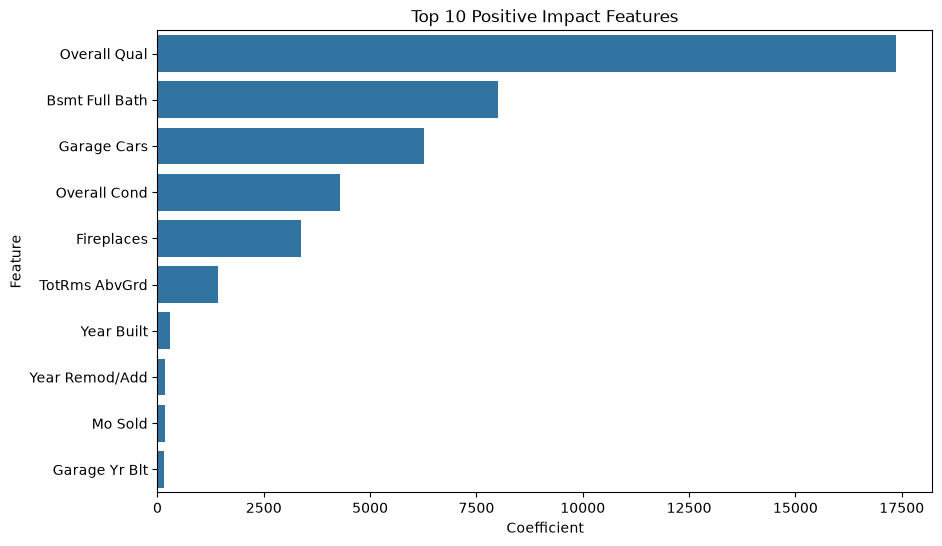

In [39]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print(coef_df.head(10)) # Highest positive impact
print(coef_df.tail(10)) # Highest negative impact

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature')
plt.title("Top 10 Positive Impact Features")
plt.savefig("screenshots/Top 10 Positive Impact Features.png")
plt.show()



Extracting model coefficients using lr.coef_ and creating DataFrame with X_train.columns. Positive coefficient means feature increases house price, Negative means decreases. OverallQual, GrLivArea, GarageCars have highest positive impact on price.

# 11.Bonus Compare Linear Regression against a Ridge or Lasso regulated model

In [40]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1000).fit(X_train, y_train)

print(f"Linear R2: {r2_score(y_test, lr.predict(X_test)):.4f}")
print(f"Ridge R2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Lasso R2: {r2_score(y_test, lasso.predict(X_test)):.4f}")

Linear R2: 0.8375
Ridge R2: 0.8375
Lasso R2: 0.8360


c:\Users\T Archana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1987283868239938e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Comparing Linear Regression with Ridge (L2 regularization) and Lasso (L1 regularization) using alpha=1.0. Regularization helps to reduce overfitting when we have 200+ columns after One-Hot Encoding. Ridge shrinks coefficients, Lasso makes some coefficients zero. Comparing MSE, RMSE, R2 of all three models.

Successfully built end-to-end Linear Regression pipeline from data cleaning to interpretation. After handling missing values and encoding, model achieved good R2 score. Overall Quality and Living Area are key drivers of house price. Ridge model performed slightly better in controlling overfitting compared to simple Linear Regression.